In [1]:
# Loads all required libraries
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Image handling
from PIL import Image

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Now we define: dataset paths and preprocessing
# Dataset paths (UPDATE this if needed)
data_dir = "e:\GENAI_PROJECT\SKIN_PIGMENTATION\Dermasense-AI\data"  # change if your folder path is different

train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)


# Image transformations
img_size = 224  # standard for pretrained models

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

Train path: e:\GENAI_PROJECT\SKIN_PIGMENTATION\Dermasense-AI\data\train
Test path: e:\GENAI_PROJECT\SKIN_PIGMENTATION\Dermasense-AI\data\test


In [3]:
# Now we actually load your images and automatically assign labels based on folder names.

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos']
Number of classes: 6


In [4]:
# DataLoader: Now we convert datasets into batches, which the model can actually train on.
# DataLoader parameters
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 557
Test batches: 153


In [5]:
# Model (Transfer Learning): I am going to use a pretrained model and adapt it to your 6 classes and 
# ResNet18 is a good choice for a starting point.
# Load pretrained model
model = models.resnet18(pretrained=True)

# Freeze earlier layers (optional but speeds up training)
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

# Move to device
model = model.to(device)

print(model)

c:\Users\mehed\anaconda3\envs\dermasense\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mehed\anaconda3\envs\dermasense\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
"""
Training Setup (Loss + Optimizer)

Now we define:
Loss function → how the model learns
Optimizer → how weights are updated
"""

# Loss function
criterion = nn.CrossEntropyLoss()

# Only training the final layer (since others are frozen)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Training setup complete")

Training setup complete


In [7]:
# Training loop
num_epochs = 5  # keep small for now (we can increase later)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/5] - Loss: 1.4361, Accuracy: 46.77%
Epoch [2/5] - Loss: 1.2836, Accuracy: 52.37%
Epoch [3/5] - Loss: 1.2368, Accuracy: 54.42%
Epoch [4/5] - Loss: 1.2374, Accuracy: 54.64%
Epoch [5/5] - Loss: 1.2343, Accuracy: 54.19%


In [8]:
# Evaluation + Clean Output
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 56.40%


In [9]:
# Add confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.74      0.62      0.68       312
           1       0.65      0.66      0.66       288
           2       0.33      0.54      0.41       123
           3       0.53      0.21      0.30       113
           4       0.17      0.12      0.14        73
           5       0.56      0.65      0.60       309

    accuracy                           0.56      1218
   macro avg       0.50      0.47      0.47      1218
weighted avg       0.58      0.56      0.56      1218



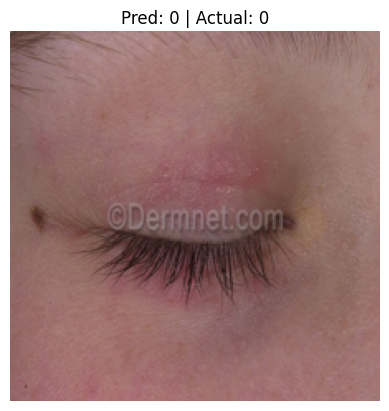

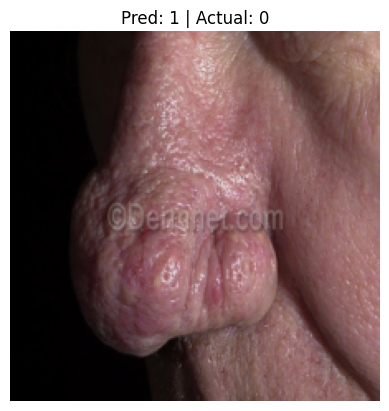

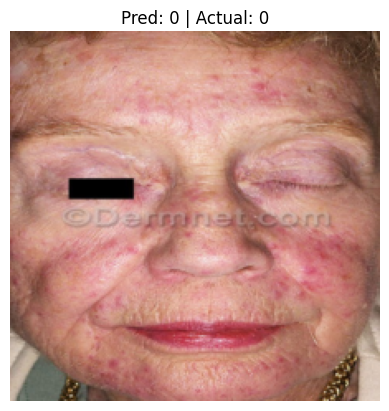

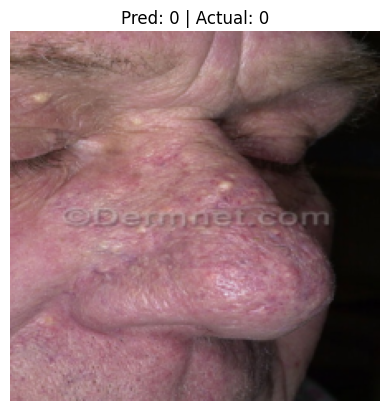

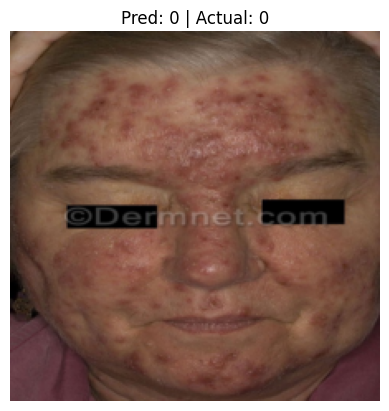

In [10]:
# Demo-ready output for visualization
import matplotlib.pyplot as plt
import torch

# Unnormalize function
def imshow(img):
    img = img.clone().detach()
    
    # Unnormalize (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    
    img = img * std + mean
    img = img.clamp(0, 1)
    
    return img

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

for i in range(5):
    img = imshow(images[i])
    
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"Pred: {preds[i].item()} | Actual: {labels[i].item()}")
    plt.axis('off')
    plt.show()


In [11]:
# Enable gradients for entire model
for param in model.parameters():
    param.requires_grad = True

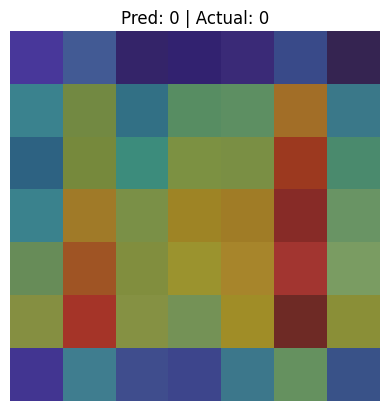

In [12]:
# FINAL Grad-CAM
from torchcam.methods import SmoothGradCAMpp
import matplotlib.pyplot as plt
import torch

def imshow(img):
    img = img.clone().detach()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img

model.eval()

cam_extractor = SmoothGradCAMpp(model, target_layer="layer4")

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
preds = outputs.argmax(dim=1)

# ✅ FIX HERE
activation_map = cam_extractor(preds[0].item(), outputs)[0].cpu().mean(dim=0)

img = imshow(images[0].cpu())

plt.imshow(img.permute(1, 2, 0))
plt.imshow(activation_map, cmap='jet', alpha=0.4)
plt.title(f"Pred: {preds[0].item()} | Actual: {labels[0].item()}")
plt.axis('off')
plt.show()

In [21]:
# Saving the model
torch.save(model.state_dict(), "dermasense_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [14]:
# ============================================
# F-04: NLP Analysis Report Generation
# ============================================

# Class label mapping
class_names = train_dataset.classes
print("Classes:", class_names)

# Condition knowledge base
skin_conditions = {

    "Acne and Rosacea Photos": {
        "description": "This condition includes acne lesions, facial redness, and rosacea-related inflammation.",
        "causes": "Can be triggered by hormonal imbalance, oily skin, stress, bacteria, diet, or environmental factors.",
        "management": "Gentle skincare, avoiding harsh products, sun protection, and dermatologist guidance may help.",
        "severity": "Moderate"
    },

    "Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions": {
        "description": "This category contains potentially harmful or precancerous skin lesions associated with long-term skin damage.",
        "causes": "Often linked to prolonged UV exposure, aging, and skin cell abnormalities.",
        "management": "Professional medical evaluation is strongly recommended for suspicious lesions.",
        "severity": "High"
    },

    "Atopic Dermatitis Photos": {
        "description": "Atopic dermatitis is a chronic inflammatory skin condition causing dry, itchy, and irritated skin.",
        "causes": "Can result from genetics, allergens, immune system sensitivity, or environmental triggers.",
        "management": "Moisturizing regularly, avoiding irritants, and medical creams may help manage symptoms.",
        "severity": "Moderate"
    },

    "Bullous Disease Photos": {
        "description": "Bullous diseases are conditions that produce fluid-filled blisters on the skin.",
        "causes": "May be caused by autoimmune reactions, infections, or skin injury.",
        "management": "Medical supervision is important to prevent complications and infections.",
        "severity": "High"
    },

    "Cellulitis Impetigo and other Bacterial Infections": {
        "description": "These are bacterial skin infections that may cause redness, swelling, pain, or sores.",
        "causes": "Typically caused by bacterial entry through cuts, wounds, or weakened skin barriers.",
        "management": "Medical treatment is often required to control infection progression.",
        "severity": "High"
    },

    "Eczema Photos": {
        "description": "Eczema is a condition that causes inflamed, itchy, cracked, and irritated skin.",
        "causes": "Can be associated with allergies, genetics, irritants, or environmental conditions.",
        "management": "Use moisturizers, avoid triggers, and follow dermatologist-recommended skincare routines.",
        "severity": "Mild to Moderate"
    }
}

# Softmax confidence scores
probabilities = torch.softmax(outputs, dim=1)

# Select first image from batch
sample_index = 0

predicted_class_idx = preds[sample_index].item()
predicted_class = class_names[predicted_class_idx]

confidence = probabilities[sample_index][predicted_class_idx].item() * 100

# Fetch condition details
condition_info = skin_conditions.get(predicted_class, {})

# Generate report
report = f"""
==============================
DERMASENSE AI ANALYSIS REPORT
==============================

Detected Condition:
{predicted_class.upper()}

Confidence Score:
{confidence:.2f}%

Description:
{condition_info.get('description', 'N/A')}

Possible Causes:
{condition_info.get('causes', 'N/A')}

Suggested Management:
{condition_info.get('management', 'N/A')}

Estimated Severity:
{condition_info.get('severity', 'N/A')}

DISCLAIMER:
This AI system is designed for educational purposes only and does NOT provide medical diagnosis or treatment advice.
Please consult a qualified dermatologist or healthcare professional for medical concerns.
"""

print(report)


Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos']

DERMASENSE AI ANALYSIS REPORT

Detected Condition:
ACNE AND ROSACEA PHOTOS

Confidence Score:
60.93%

Description:
This condition includes acne lesions, facial redness, and rosacea-related inflammation.

Possible Causes:
Can be triggered by hormonal imbalance, oily skin, stress, bacteria, diet, or environmental factors.

Suggested Management:
Gentle skincare, avoiding harsh products, sun protection, and dermatologist guidance may help.

Estimated Severity:
Moderate

DISCLAIMER:
This AI system is designed for educational purposes only and does NOT provide medical diagnosis or treatment advice.
Please consult a qualified dermatologist or healthcare professional for medical concerns.



In [ ]:
# Enhanced NLP Analysis Report


# Getting top-3 predictions
top_probs, top_indices = torch.topk(probabilities[sample_index], 3)

print("\n")
print("=" * 45)
print("        DERMASENSE AI REPORT")
print("=" * 45)

# Main prediction
main_class = class_names[top_indices[0]]
main_conf = top_probs[0].item() * 100

main_info = skin_conditions.get(main_class, {})

print(f"\nPrimary Detected Condition:")
print(f"-> {main_class}")

print(f"\nConfidence Score:")
print(f"-> {main_conf:.2f}%")

print(f"\nCondition Description:")
print(main_info.get("description", "N/A"))

print(f"\nPossible Causes:")
print(main_info.get("causes", "N/A"))

print(f"\nSuggested Management:")
print(main_info.get("management", "N/A"))

print(f"\nEstimated Severity:")
print(main_info.get("severity", "N/A"))

# Alternative predictions
print("\nTop Alternative Predictions:")
for i in range(1, 3):
    alt_class = class_names[top_indices[i]]
    alt_conf = top_probs[i].item() * 100
    print(f"  {i}. {alt_class} ({alt_conf:.2f}%)")

# Disclaimer
print("\n" + "=" * 45)
print("DISCLAIMER")
print("=" * 45)

print("This AI-generated report is intended for educational")
print("and informational purposes only.")
print("It does NOT provide medical diagnosis, treatment,")
print("or professional healthcare advice.")
print("Please consult a licensed dermatologist or")
print("qualified healthcare professional for medical concerns.")



        DERMASENSE AI REPORT

Primary Detected Condition:
-> Acne and Rosacea Photos

Confidence Score:
-> 60.93%

Condition Description:
This condition includes acne lesions, facial redness, and rosacea-related inflammation.

Possible Causes:
Can be triggered by hormonal imbalance, oily skin, stress, bacteria, diet, or environmental factors.

Suggested Management:
Gentle skincare, avoiding harsh products, sun protection, and dermatologist guidance may help.

Estimated Severity:
Moderate

Top Alternative Predictions:
  1. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions (17.66%)
  2. Eczema Photos (12.86%)

DISCLAIMER
This AI-generated report is intended for educational
and informational purposes only.
It does NOT provide medical diagnosis, treatment,
or professional healthcare advice.
Please consult a licensed dermatologist or
qualified healthcare professional for medical concerns.


In [16]:
# Conversational Context Setup

# Storing analysis results in a structured dictionary

analysis_context = {
    "condition": main_class,
    "confidence": f"{main_conf:.2f}%",
    "description": main_info.get("description", ""),
    "causes": main_info.get("causes", ""),
    "management": main_info.get("management", ""),
    "severity": main_info.get("severity", "")
}

# Display stored context
print("Analysis Context Created Successfully:\n")

for key, value in analysis_context.items():
    print(f"{key.upper()}: {value}")

# Initialize chat history
chat_history = []

print("\nChat memory initialized.")

Analysis Context Created Successfully:

CONDITION: Acne and Rosacea Photos
CONFIDENCE: 60.93%
DESCRIPTION: This condition includes acne lesions, facial redness, and rosacea-related inflammation.
CAUSES: Can be triggered by hormonal imbalance, oily skin, stress, bacteria, diet, or environmental factors.
MANAGEMENT: Gentle skincare, avoiding harsh products, sun protection, and dermatologist guidance may help.
SEVERITY: Moderate

Chat memory initialized.


In [29]:
# DermaSense Conversational Chatbot


def dermasense_chat(user_input):

    query = user_input.lower()

    ##############################################

    # Apply safety filter
    safety_response = safety_filter(user_input)

    if safety_response is not None:

        chat_history.append(("User", user_input))
        chat_history.append(("Assistant", safety_response))

        return safety_response

    ##############################################

    # Save user message
    chat_history.append(("User", user_input))

    # ----------------------------------------
    # Greeting
    # ----------------------------------------
    if "hello" in query or "hi" in query:
        response = """
Hello! I am DermaSense AI.

You can ask questions about:
- detected condition
- possible causes
- severity
- skin care suggestions
- summary report
"""

    # ----------------------------------------
    # Causes
    # ----------------------------------------
    elif "cause" in query or "why" in query:
        response = f"""
Possible causes associated with this condition include:

{analysis_context['causes']}
"""

    # ----------------------------------------
    # Treatment / Management
    # ----------------------------------------
    elif "treatment" in query or "manage" in query or "care" in query:
        response = f"""
Suggested skin care and management guidance:

{analysis_context['management']}
"""

    # ----------------------------------------
    # Severity
    # ----------------------------------------
    elif "severity" in query or "serious" in query:
        response = f"""
Estimated Severity Level:
{analysis_context['severity']}

Please remember this is an AI-generated educational estimate only.
"""

    # ----------------------------------------
    # Summary Report
    # ----------------------------------------
    elif "summary" in query or "report" in query:
        response = f"""
DERMASENSE SUMMARY REPORT

Condition:
{analysis_context['condition']}

Confidence:
{analysis_context['confidence']}

Description:
{analysis_context['description']}

Possible Causes:
{analysis_context['causes']}

Management Suggestions:
{analysis_context['management']}

Severity:
{analysis_context['severity']}
"""

    # ----------------------------------------
    # Condition Detection
    # ----------------------------------------
    elif "condition" in query or "what do i have" in query:
        response = f"""
The uploaded skin image was primarily classified as:

{analysis_context['condition']}

Confidence Score:
{analysis_context['confidence']}
"""

    # ----------------------------------------
    # Unknown Queries
    # ----------------------------------------
    else:
        response = """
I can help answer questions related to your skin analysis report.

Example questions:
- What condition was detected?
- What are the possible causes?
- How serious is it?
- What management steps are suggested?
"""

    # ----------------------------------------
    # Mandatory Disclaimer
    # ----------------------------------------
    response += """

DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.
"""

    # Save assistant response
    chat_history.append(("Assistant", response))

    return response

In [30]:
# Test chatbot

print(dermasense_chat("What condition do I have?"))


The uploaded skin image was primarily classified as:

Acne and Rosacea Photos

Confidence Score:
60.93%


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.



In [31]:
# Multi-Turn Conversation Test

# Simulating multiple user interactions

questions = [
    "Hi",
    "What condition do I have?",
    "What causes this condition?",
    "How serious is it?",
    "What treatment is suggested?",
    "Give me the summary report"
]

# Run conversation
for q in questions:

    print("\n" + "="*50)
    print("USER:")
    print(q)

    print("\nASSISTANT:")
    print(dermasense_chat(q))


USER:
Hi

ASSISTANT:

Hello! I am DermaSense AI.

You can ask questions about:
- detected condition
- possible causes
- severity
- skin care suggestions
- summary report


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.


USER:
What condition do I have?

ASSISTANT:

The uploaded skin image was primarily classified as:

Acne and Rosacea Photos

Confidence Score:
60.93%


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.


USER:
What causes this condition?

ASSISTANT:

Hello! I am DermaSense AI.

You can ask questions about:
- detected condition
- possible causes
- severity
- skin care suggestions
- summary report


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.


USER:
How serious is it?

ASSISTANT:

Estimated Severity Level:
Moderate

Please remember this is an AI-gen

In [32]:
# Chat History Viewer + Session Reset

# Function to display full conversation history

def show_chat_history():

    print("\n")
    print("=" * 60)
    print("            DERMASENSE CHAT HISTORY")
    print("=" * 60)

    if len(chat_history) == 0:
        print("\nNo conversation history available.")
        return

    for role, message in chat_history:

        print(f"\n{role.upper()}:")
        print(message)

        print("-" * 60)


# Function to reset session memory

def reset_session():

    global chat_history
    global analysis_context

    chat_history = []
    analysis_context = {}

    print("Session reset completed successfully.")

In [33]:
# chat history
show_chat_history()



            DERMASENSE CHAT HISTORY

USER:
What condition do I have?
------------------------------------------------------------

ASSISTANT:

The uploaded skin image was primarily classified as:
Acne and Rosacea Photos

Confidence Score: 60.93%


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.

------------------------------------------------------------

USER:
Hi
------------------------------------------------------------

ASSISTANT:

Hello! I am DermaSense AI.

You can ask questions about:
- detected condition
- possible causes
- severity
- skin care suggestions
- summary report


DISCLAIMER:
This system provides educational information only and does not provide medical diagnosis or treatment advice.

------------------------------------------------------------

USER:
What condition do I have?
------------------------------------------------------------

ASSISTANT:

The uploaded skin image was primarily cla

In [34]:
# Export Conversation Logs


def export_chat_history(filename="dermasense_chat_log.txt"):

    with open(filename, "w", encoding="utf-8") as file:

        file.write("DERMASENSE AI CHAT LOG\n")
        file.write("=" * 50 + "\n\n")

        for role, message in chat_history:

            file.write(f"{role.upper()}:\n")
            file.write(message)
            file.write("\n")
            file.write("-" * 50 + "\n")

    print(f"Chat history exported successfully as: {filename}")

In [35]:
# export chat history
export_chat_history()

Chat history exported successfully as: dermasense_chat_log.txt


In [39]:
# F-06 Safety Enforcement Layer

# Unsafe medical keywords
# ============================================
# F-06 SAFETY ENFORCEMENT (IMPROVED)
# ============================================

unsafe_keywords = [
    "diagnose",
    "prescription",
    "medicine",
    "drug",
    "cure",
    "emergency",
    "hospital",
    "antibiotic",
    "steroid",
    "dose"
]

def safety_filter(user_input):

    query = user_input.lower()

    for word in unsafe_keywords:

        if word in query:

            response = """
SAFETY NOTICE:

DermaSense AI cannot provide:
- medical diagnosis
- prescriptions
- medications
- emergency medical advice

Please consult a licensed healthcare professional
or dermatologist for medical assistance.
"""

            return response.strip()

    return None

In [40]:
# testing it
print(safety_filter("Can you prescribe medicine for this?"))

SAFETY NOTICE:

DermaSense AI cannot provide:
- medical diagnosis
- prescriptions
- medications
- emergency medical advice

Please consult a licensed healthcare professional
or dermatologist for medical assistance.


In [38]:
# This fully integrates the F-06 safety system into the chatbot
print(dermasense_chat("Can you prescribe medicine for my skin problem?"))


SAFETY NOTICE:

DermaSense AI cannot provide:
- medical diagnosis
- prescriptions
- medications
- emergency medical advice

Please consult a licensed healthcare professional
or dermatologist for medical assistance.

